# Decision tree classification

This notebook uses a decision tree to predict whether a person earns more than $50K per year from the Adult Income dataset (1994 US Census).


## Import libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42
N_FOLDS = 5

print("Libraries loaded.")

Libraries loaded.


In [2]:
train = pd.read_csv("cleaned_data/train_encoded.csv")
test = pd.read_csv("cleaned_data/test_encoded.csv")

X_train = train.drop(columns="income")
y_train = train["income"].astype(int)

# Make sure test has exactly the same columns, in the same order, as train
X_test = test.drop(columns="income").reindex(columns=X_train.columns, fill_value=0)
y_test = test["income"].astype(int)

assert y_test.nunique() == 2, "The test set has only one income class. Check the cleaned data."

feature_names = X_train.columns.tolist()

print("Training set:", X_train.shape)    # expected (30139, 42)
print("Test set:    ", X_test.shape)     # expected (15055, 42)
print("Missing values:", X_train.isna().sum().sum() + X_test.isna().sum().sum())
print("Non-numeric columns:", X_train.select_dtypes(exclude="number").columns.tolist())
print("Income values:", sorted(y_train.unique().tolist()))

display(X_train.head())

Training set: (30139, 42)
Test set:     (15055, 42)
Missing values: 0
Non-numeric columns: []
Income values: [0, 1]


,age,education-num,sex,hours-per-week,capital-gain-log,capital-loss-log,has-capital,is_us,workclass_Local-gov,workclass_Private,...,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,39,13,1,40,7.684784,0.0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,1
1,50,13,1,13,0.000000,0.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,38,9,1,40,0.000000,0.0,0,1,0,1,...,0,1,0,0,0,0,0,0,0,1
3,53,7,1,40,0.000000,0.0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,13,0,40,0.000000,0.0,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0


#### Target variable distribution

In [3]:
class_summary = pd.DataFrame({
    "Train count": y_train.value_counts().sort_index(),
    "Train (%)": y_train.value_counts(normalize=True).sort_index().mul(100),
    "Test count": y_test.value_counts().sort_index(),
    "Test (%)": y_test.value_counts(normalize=True).sort_index().mul(100)
})
class_summary.index = ["<=50K (0)", ">50K (1)"]
display(class_summary.round(2))

print("The classes are imbalanced (about 75% / 25%), so accuracy alone can be misleading.")
print("The F1-score for the >50K class is used to select the best tree settings.")

,Train count,Train (%),Test count,Test (%)
<=50K (0),22633,75.1,11355,75.42
>50K (1),7506,24.9,3700,24.58


The classes are imbalanced (about 75% / 25%), so accuracy alone can be misleading.
The F1-score for the >50K class is used to select the best tree settings.


## 3. Splitting the dataset

Two levels of splitting are used:

1. Hold-out test set: the dataset comes with a separate test file (`adult.test`), which is used only once, for the final evaluation of the chosen model.
2. Stratified 5-fold cross-validation on the training set: used to compare trees with different settings. The training data is split into 5 parts. Each tree is trained on 4 parts and evaluated on the 5th, five times, and the results are averaged. Stratified means every fold keeps the same 75% / 25% class ratio.

This way the tree settings are chosen without looking at the test set, so the final test result is an honest estimate of performance on new data.

In [4]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# zero_division=0: a very shallow tree may never predict >50K; precision is then reported as 0
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

print("Fold sizes and share of >50K in each validation fold:")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    print(f"Fold {fold}: train = {len(train_idx)}, validation = {len(val_idx)}, "
          f">50K share = {y_train.iloc[val_idx].mean():.3f}")


def evaluate_tree(**tree_params):
    """Cross-validate a decision tree with the given settings and return mean scores."""
    tree = DecisionTreeClassifier(random_state=RANDOM_STATE, **tree_params)
    scores = cross_validate(tree, X_train, y_train, cv=cv, scoring=scoring,
                            return_train_score=True)
    result = {name: scores[f"test_{name}"].mean() for name in scoring}
    result["train_f1"] = scores["train_f1"].mean()
    result["train_accuracy"] = scores["train_accuracy"].mean()
    result["f1_std"] = scores["test_f1"].std()
    return result

Fold sizes and share of >50K in each validation fold:
Fold 1: train = 24111, validation = 6028, >50K share = 0.249
Fold 2: train = 24111, validation = 6028, >50K share = 0.249
Fold 3: train = 24111, validation = 6028, >50K share = 0.249
Fold 4: train = 24111, validation = 6028, >50K share = 0.249
Fold 5: train = 24112, validation = 6027, >50K share = 0.249


## Decision trees of varying depth

In [5]:
depths = list(range(1, 26)) + [None]

depth_results = []
for depth in depths:
    result = evaluate_tree(max_depth=depth)
    result["max_depth"] = "None" if depth is None else depth
    depth_results.append(result)

depth_results = pd.DataFrame(depth_results).set_index("max_depth")

display(depth_results[["train_accuracy", "accuracy", "train_f1", "f1", "precision", "recall", "roc_auc"]]
        .rename(columns={"accuracy": "cv_accuracy", "f1": "cv_f1", "precision": "cv_precision",
                         "recall": "cv_recall", "roc_auc": "cv_roc_auc"})
        .round(4))

,train_accuracy,cv_accuracy,train_f1,cv_f1,cv_precision,cv_recall,cv_roc_auc
max_depth,,,,,,,
1,0.7510,0.7510,0.0000,0.0000,0.0000,0.0000,0.7569
2,0.8242,0.8240,0.5578,0.5571,0.7459,0.4446,0.8292
3,0.8402,0.8400,0.6144,0.6137,0.7696,0.5104,0.8559
4,0.8423,0.8415,0.6195,0.6182,0.7728,0.5155,0.8685
5,0.8467,0.8454,0.6261,0.6229,0.7935,0.5129,0.8838
6,0.8526,0.8499,0.6468,0.6400,0.7951,0.5356,0.8924
7,0.8558,0.8509,0.6600,0.6475,0.7869,0.5506,0.8993
8,0.8601,0.8538,0.6752,0.6607,0.7840,0.5715,0.8998
9,0.8641,0.8534,0.6916,0.6674,0.7690,0.5917,0.8990


Best max_depth (highest cross-validated F1) = 9


,accuracy,precision,recall,f1,roc_auc
max_depth,,,,,
9,0.8534,0.769,0.5917,0.6674,0.899


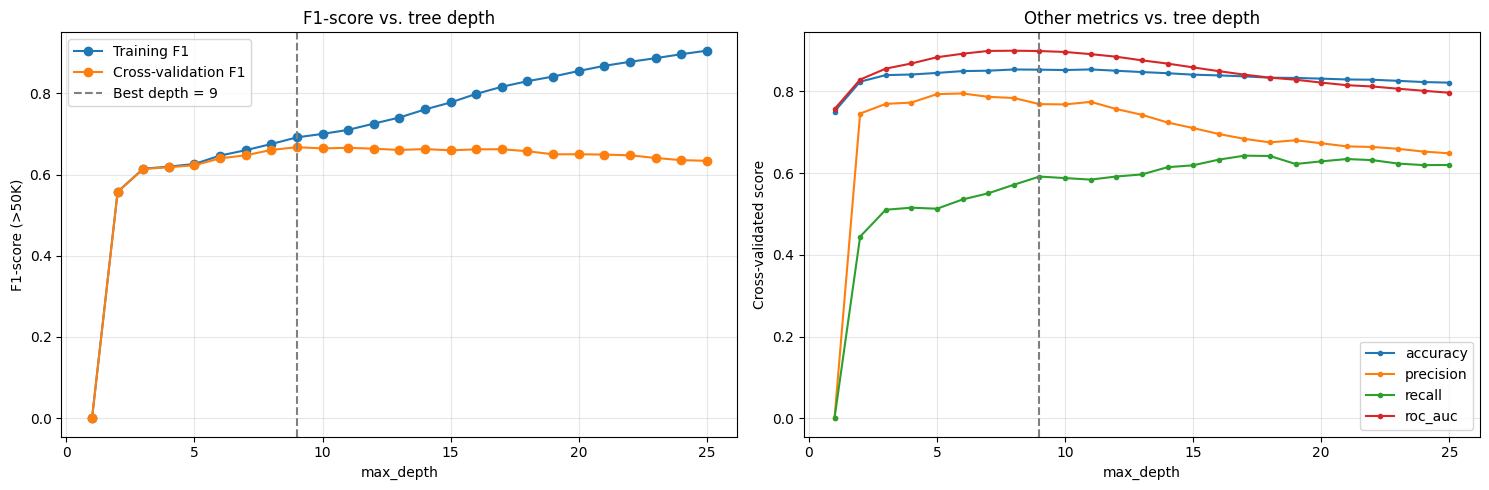

In [6]:
best_depth = depth_results["f1"].idxmax()
print(f"Best max_depth (highest cross-validated F1) = {best_depth}")
display(depth_results.loc[[best_depth], ["accuracy", "precision", "recall", "f1", "roc_auc"]].round(4))

numeric_depths = depth_results.drop(index="None")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(numeric_depths.index, numeric_depths["train_f1"], marker="o", label="Training F1")
axes[0].plot(numeric_depths.index, numeric_depths["f1"], marker="o", label="Cross-validation F1")
axes[0].axvline(best_depth, color="grey", linestyle="--", label=f"Best depth = {best_depth}")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("F1-score (>50K)")
axes[0].set_title("F1-score vs. tree depth")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for metric in ["accuracy", "precision", "recall", "roc_auc"]:
    axes[1].plot(numeric_depths.index, numeric_depths[metric], marker=".", label=metric)
axes[1].axvline(best_depth, color="grey", linestyle="--")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Cross-validated score")
axes[1].set_title("Other metrics vs. tree depth")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Decision trees with varying numbers of samples in the leaf nodes

`min_samples_leaf` is the minimum number of training observations every leaf must contain. A leaf with very few people produces a decision based on a handful of cases, which is unreliable. Larger values make the tree simpler and more stable.

Here the depth is not limited, so the effect of `min_samples_leaf` alone can be seen.

In [7]:
leaf_sizes = [1, 2, 5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500, 750, 1000]

leaf_results = []
for leaf_size in leaf_sizes:
    result = evaluate_tree(min_samples_leaf=leaf_size)
    result["min_samples_leaf"] = leaf_size
    leaf_results.append(result)

leaf_results = pd.DataFrame(leaf_results).set_index("min_samples_leaf")

display(leaf_results[["train_accuracy", "accuracy", "train_f1", "f1", "precision", "recall", "roc_auc"]]
        .rename(columns={"accuracy": "cv_accuracy", "f1": "cv_f1", "precision": "cv_precision",
                         "recall": "cv_recall", "roc_auc": "cv_roc_auc"})
        .round(4))

,train_accuracy,cv_accuracy,train_f1,cv_f1,cv_precision,cv_recall,cv_roc_auc
min_samples_leaf,,,,,,,
1,0.9774,0.8170,0.9531,0.6240,0.6388,0.6100,0.7674
2,0.9309,0.8265,0.8482,0.6201,0.6821,0.5685,0.8086
5,0.8997,0.8379,0.7856,0.6530,0.6995,0.6123,0.8633
10,0.8822,0.8482,0.7421,0.6671,0.7350,0.6108,0.8855
15,0.8754,0.8510,0.7264,0.6737,0.7408,0.6179,0.8933
20,0.8721,0.8534,0.7185,0.6777,0.7488,0.6191,0.8981
30,0.8671,0.8526,0.7058,0.6739,0.7506,0.6115,0.9022
50,0.8618,0.8526,0.6927,0.6712,0.7557,0.6038,0.9057
75,0.8583,0.8527,0.6811,0.6674,0.7628,0.5933,0.9044


Best min_samples_leaf (highest cross-validated F1) = 20


,accuracy,precision,recall,f1,roc_auc
min_samples_leaf,,,,,
20,0.8534,0.7488,0.6191,0.6777,0.8981


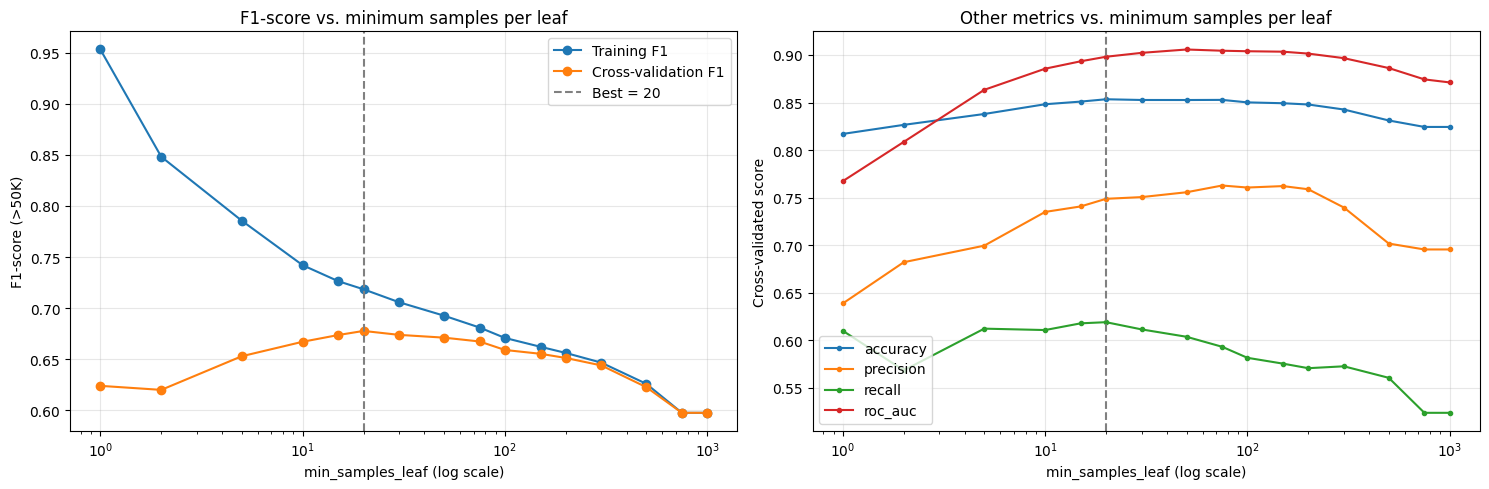

In [8]:
best_leaf = leaf_results["f1"].idxmax()
print(f"Best min_samples_leaf (highest cross-validated F1) = {best_leaf}")
display(leaf_results.loc[[best_leaf], ["accuracy", "precision", "recall", "f1", "roc_auc"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(leaf_results.index, leaf_results["train_f1"], marker="o", label="Training F1")
axes[0].plot(leaf_results.index, leaf_results["f1"], marker="o", label="Cross-validation F1")
axes[0].axvline(best_leaf, color="grey", linestyle="--", label=f"Best = {best_leaf}")
axes[0].set_xscale("log")
axes[0].set_xlabel("min_samples_leaf (log scale)")
axes[0].set_ylabel("F1-score (>50K)")
axes[0].set_title("F1-score vs. minimum samples per leaf")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for metric in ["accuracy", "precision", "recall", "roc_auc"]:
    axes[1].plot(leaf_results.index, leaf_results[metric], marker=".", label=metric)
axes[1].axvline(best_leaf, color="grey", linestyle="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("min_samples_leaf (log scale)")
axes[1].set_ylabel("Cross-validated score")
axes[1].set_title("Other metrics vs. minimum samples per leaf")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Combining the two settings

Depth and leaf size both control tree complexity, so they interact. To build the final model, both are tuned together over a grid around the best values found above, again using cross-validation on the training set only.

Best combination: max_depth = None, min_samples_leaf = 20
Cross-validated F1 = 0.6777, accuracy = 0.8534


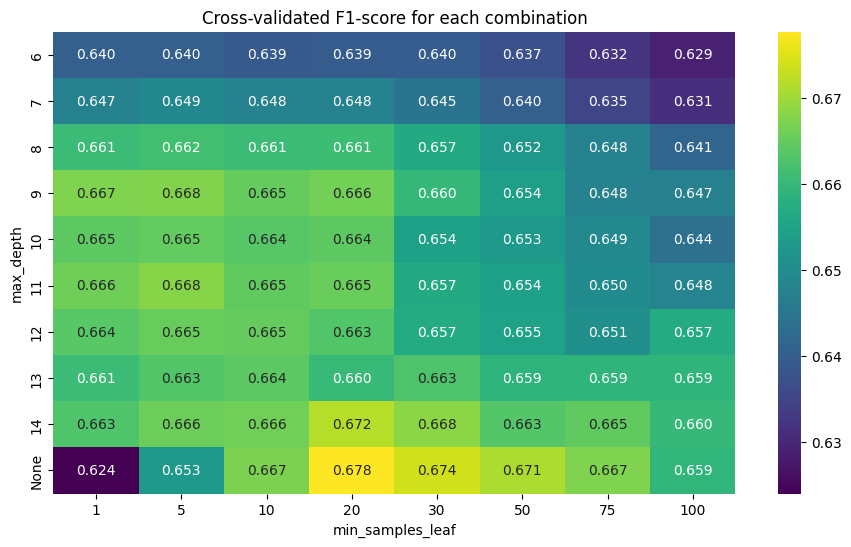

In [9]:
depth_grid = [d for d in range(max(2, best_depth - 3), best_depth + 6)] + [None]
leaf_grid = sorted(set([1, 5, 10, 20, 30, 50, 75, 100, best_leaf]))

combined_results = []
for depth in depth_grid:
    for leaf_size in leaf_grid:
        result = evaluate_tree(max_depth=depth, min_samples_leaf=leaf_size)
        result["max_depth"] = "None" if depth is None else depth
        result["min_samples_leaf"] = leaf_size
        combined_results.append(result)

combined_results = pd.DataFrame(combined_results)

best_row = combined_results.loc[combined_results["f1"].idxmax()]
final_depth = None if best_row["max_depth"] == "None" else int(best_row["max_depth"])
final_leaf = int(best_row["min_samples_leaf"])

print(f"Best combination: max_depth = {final_depth}, min_samples_leaf = {final_leaf}")
print(f"Cross-validated F1 = {best_row['f1']:.4f}, accuracy = {best_row['accuracy']:.4f}")

heatmap_data = combined_results.pivot(index="max_depth", columns="min_samples_leaf", values="f1")
heatmap_data = heatmap_data.reindex(["None" if d is None else d for d in depth_grid])

plt.figure(figsize=(11, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.title("Cross-validated F1-score for each combination")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.show()

#### Comparison of the candidate models on the training data (cross-validation)

In [10]:
candidates = {
    "Default tree (no limits)": dict(),
    f"Best depth (max_depth={best_depth})": dict(max_depth=best_depth),
    f"Best leaf size (min_samples_leaf={best_leaf})": dict(min_samples_leaf=best_leaf),
    f"Final (max_depth={final_depth}, min_samples_leaf={final_leaf})": dict(max_depth=final_depth, min_samples_leaf=final_leaf),
}

candidate_results = pd.DataFrame({name: evaluate_tree(**params) for name, params in candidates.items()}).T
display(candidate_results[["train_accuracy", "accuracy", "precision", "recall", "f1", "roc_auc"]]
        .rename(columns={"accuracy": "cv_accuracy", "precision": "cv_precision", "recall": "cv_recall",
                         "f1": "cv_f1", "roc_auc": "cv_roc_auc"})
        .round(4))

,train_accuracy,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc
Default tree (no limits),0.9774,0.8170,0.6388,0.6100,0.6240,0.7674
Best depth (max_depth=9),0.8641,0.8534,0.7690,0.5917,0.6674,0.8990
Best leaf size (min_samples_leaf=20),0.8721,0.8534,0.7488,0.6191,0.6777,0.8981
"Final (max_depth=None, min_samples_leaf=20)",0.8721,0.8534,0.7488,0.6191,0.6777,0.8981


## Final model: evaluation on the test set

The final tree is trained on the whole training set with the selected settings and evaluated once on the test set.

In [11]:
final_tree = DecisionTreeClassifier(
    max_depth=final_depth,
    min_samples_leaf=final_leaf,
    random_state=RANDOM_STATE
)
final_tree.fit(X_train, y_train)

y_prob_tree = final_tree.predict_proba(X_test)[:, 1]
y_pred_tree = final_tree.predict(X_test)

def classification_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    return metrics

tree_metrics = classification_metrics(y_test, y_pred_tree, y_prob_tree)

display(pd.DataFrame(tree_metrics, index=["Decision tree (test set)"]).round(4))

print(f"Baseline accuracy (always predicting <=50K) = {1 - y_test.mean():.4f}")
print(f"Training accuracy = {final_tree.score(X_train, y_train):.4f}   Test accuracy = {tree_metrics['Accuracy']:.4f}")

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Decision tree (test set),0.8503,0.7416,0.5997,0.6632,0.8959


Baseline accuracy (always predicting <=50K) = 0.7542
Training accuracy = 0.8715   Test accuracy = 0.8503


#### Classification report

In [12]:
print(classification_report(y_test, y_pred_tree, target_names=["No (<=50K)", "Yes (>50K)"], zero_division=0))

              precision    recall  f1-score   support

  No (<=50K)       0.88      0.93      0.90     11355
  Yes (>50K)       0.74      0.60      0.66      3700

    accuracy                           0.85     15055
   macro avg       0.81      0.77      0.78     15055
weighted avg       0.84      0.85      0.84     15055



#### Model characteristics

In [13]:
characteristics = pd.DataFrame({
    "Value": [
        final_tree.get_depth(),
        final_tree.get_n_leaves(),
        final_tree.tree_.node_count,
        final_tree.tree_.node_count - final_tree.get_n_leaves(),
        int((final_tree.feature_importances_ > 0).sum()),
        len(feature_names),
    ]
}, index=[
    "Actual tree depth",
    "Number of leaves (= decision rules)",
    "Total number of nodes",
    "Number of internal (split) nodes",
    "Features used in at least one split",
    "Features available",
])
display(characteristics)

feature_importance = (pd.Series(final_tree.feature_importances_, index=feature_names)
                      .sort_values(ascending=False))
print("Top 10 most important features (share of total impurity reduction):")
display(feature_importance.head(10).round(4).to_frame("Importance"))

,Value
Actual tree depth,27
Number of leaves (= decision rules),731
Total number of nodes,1461
Number of internal (split) nodes,730
Features used in at least one split,35
Features available,42


Top 10 most important features (share of total impurity reduction):


,Importance
marital-status_Married-civ-spouse,0.3720
education-num,0.2094
capital-gain-log,0.1639
age,0.0754
capital-loss-log,0.0496
hours-per-week,0.0422
has-capital,0.0189
occupation_Exec-managerial,0.0116
workclass_Self-emp-not-inc,0.0069
relationship_Wife,0.0067


## Visualisation of the results

#### Confusion matrix

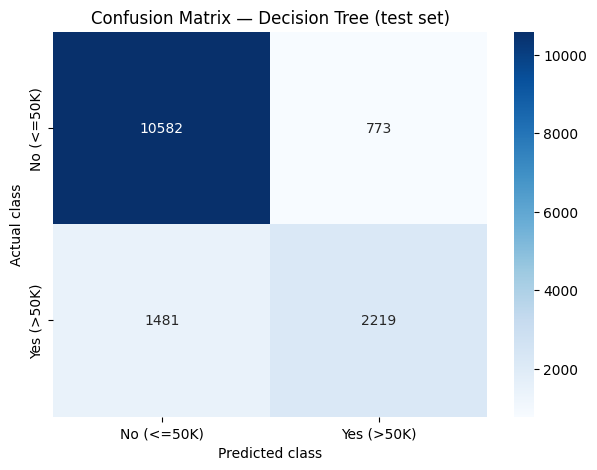

True negatives  (correctly predicted <=50K): 10582
False positives (predicted >50K, actually <=50K): 773
False negatives (predicted <=50K, actually >50K): 1481
True positives  (correctly predicted >50K): 2219


In [14]:
cm = confusion_matrix(y_test, y_pred_tree, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No (<=50K)", "Yes (>50K)"],
            yticklabels=["No (<=50K)", "Yes (>50K)"])
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Confusion Matrix — Decision Tree (test set)")
plt.show()

print(f"True negatives  (correctly predicted <=50K): {tn}")
print(f"False positives (predicted >50K, actually <=50K): {fp}")
print(f"False negatives (predicted <=50K, actually >50K): {fn}")
print(f"True positives  (correctly predicted >50K): {tp}")

#### ROC curve

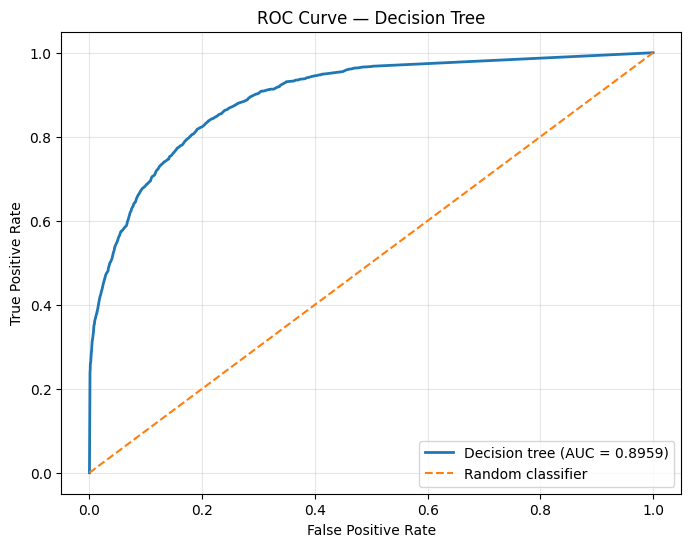

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_prob_tree)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Decision tree (AUC = {tree_metrics['ROC-AUC']:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Feature importance

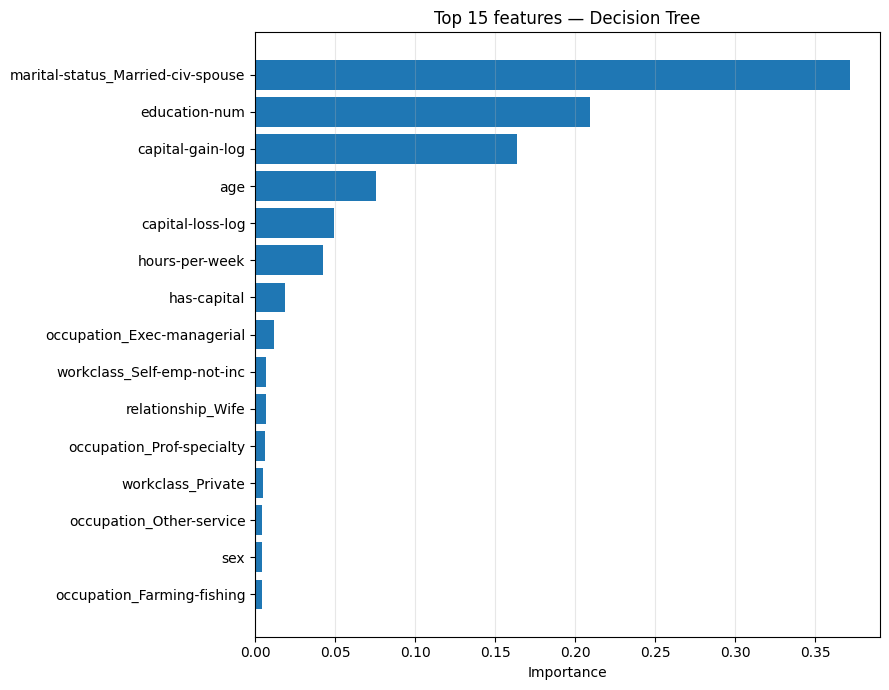

In [16]:
top_features = feature_importance.head(15).sort_values()

plt.figure(figsize=(9, 7))
plt.barh(top_features.index, top_features.values)
plt.xlabel("Importance")
plt.title("Top 15 features — Decision Tree")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### The decision tree (top levels)

The full tree is too large to read, so only the first 3 levels are drawn. Each box shows the split condition, the Gini impurity, the number of training samples, the class counts `[<=50K, >50K]` and the majority class.

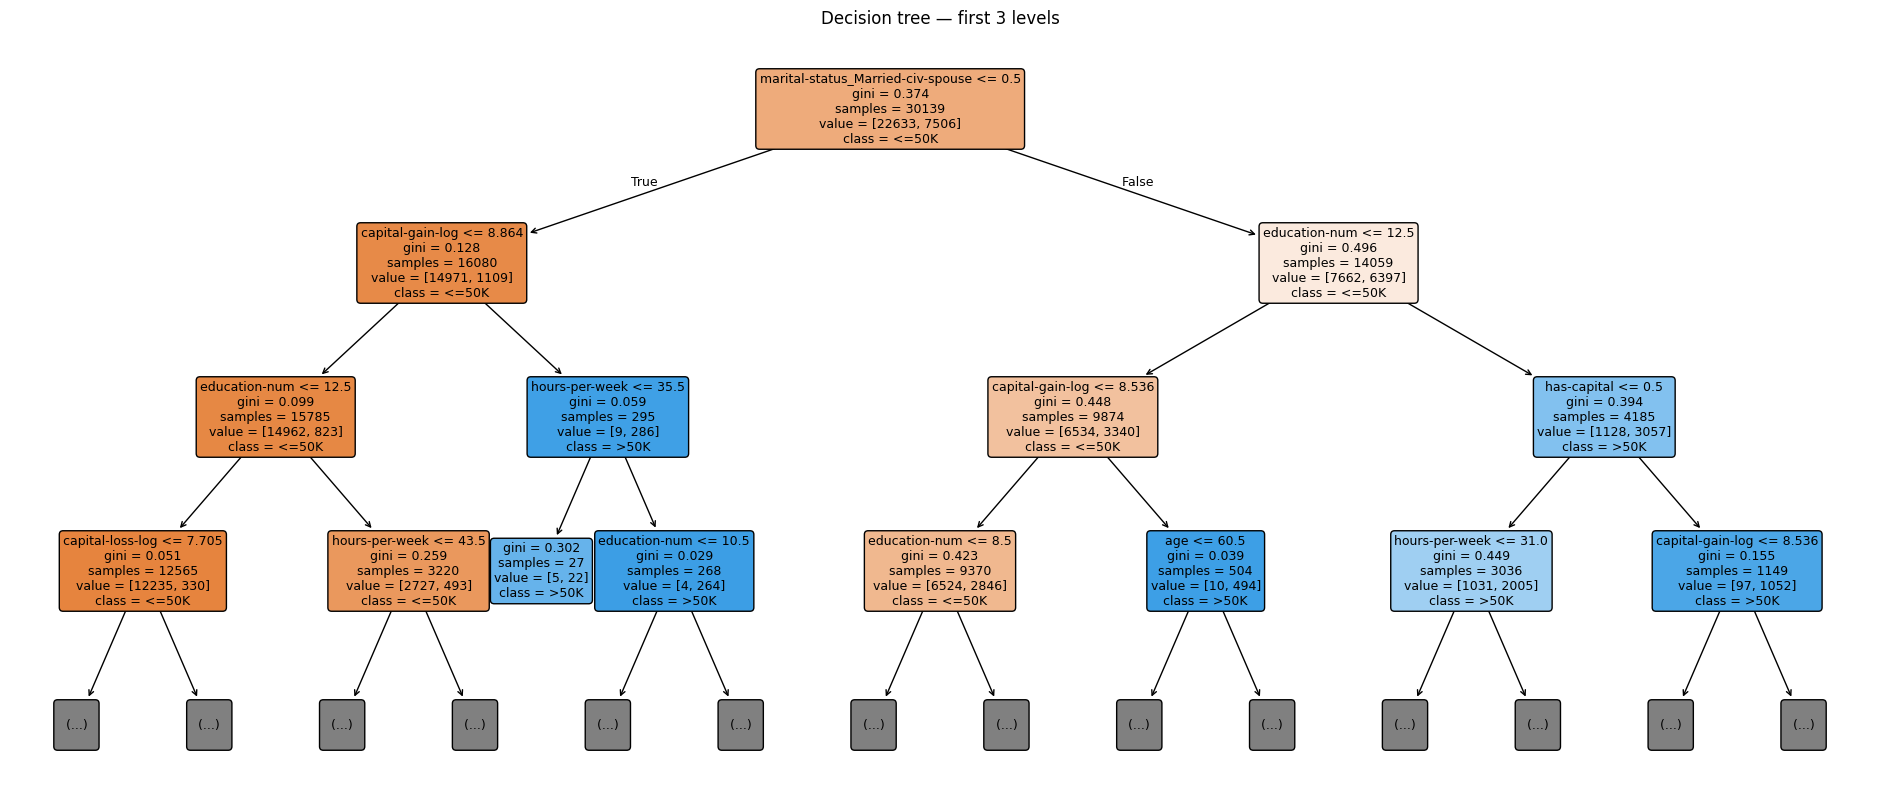

In [17]:
plt.figure(figsize=(24, 10))
plot_tree(
    final_tree,
    max_depth=3,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=9
)
plt.title("Decision tree — first 3 levels")
plt.show()

## Decision rules induced from the decision tree

Every path from the root of the tree to a leaf is an IF … THEN … rule. The final tree has hundreds of leaves, and its rules are long (often 8–10 conditions), so they are hard to read. The rule-based classifier is built in four steps, similar to the classic C4.5rules method:

1. Rule extraction: one rule per leaf. Conditions on the same variable are merged (for example, `age > 30` and `age > 40` become `age > 40`), and 0/1 variables are written as `= 1` or `= 0`.
2. Rule simplification: each rule is shortened by removing conditions one at a time, as long as its confidence on the training data (the share of covered people in the predicted class) does not drop. This removes conditions the tree needed for other branches but that do not matter for this rule. Duplicate rules are then removed.
3. Rule selection:*only rules predicting >50K are kept, with support (number of training people covered) ≥ `MIN_SUPPORT` and confidence ≥ `MIN_CONFIDENCE`.
4. Classification: IF a person matches at least one selected rule → >50K, ELSE → ≤50K (the default, majority class).

Learning rules for the minority class with the majority class as default is a standard approach in rule induction (it is also how the RIPPER algorithm works). It gives a short, readable model: "these are the profiles of high earners; everyone else is predicted ≤50K".

In [18]:
binary_features = {f for f in feature_names if set(X_train[f].unique()) <= {0, 1}}
feature_index = {f: i for i, f in enumerate(feature_names)}

X_train_array = X_train.to_numpy(dtype=float)
X_test_array = X_test.to_numpy(dtype=float)
y_train_array = y_train.to_numpy()


def extract_rules(tree):
    """One rule per leaf, as a dict {feature: (lower, upper)} meaning lower < feature <= upper."""
    t = tree.tree_
    rules = []

    def walk(node, bounds):
        if t.children_left[node] == -1:          # leaf
            rules.append(dict(bounds))
            return
        feature = feature_names[t.feature[node]]
        threshold = t.threshold[node]
        lower, upper = bounds.get(feature, (-np.inf, np.inf))

        left = dict(bounds)                       # feature <= threshold
        left[feature] = (lower, min(upper, threshold))
        walk(t.children_left[node], left)

        right = dict(bounds)                      # feature > threshold
        right[feature] = (max(lower, threshold), upper)
        walk(t.children_right[node], right)

    walk(0, {})
    return rules


def rule_mask(bounds, X_array):
    """Boolean mask of the rows that satisfy all conditions of a rule."""
    mask = np.ones(len(X_array), dtype=bool)
    for feature, (lower, upper) in bounds.items():
        values = X_array[:, feature_index[feature]]
        mask &= (values > lower) & (values <= upper)
    return mask


def rule_quality(bounds):
    """Support and share of >50K among the training people covered by the rule."""
    covered = rule_mask(bounds, X_train_array)
    support = int(covered.sum())
    positive_share = y_train_array[covered].mean() if support > 0 else 0.0
    return support, positive_share


def condition_text(feature, lower, upper):
    if feature in binary_features:
        return f"{feature} = 1" if lower >= 0.5 else f"{feature} = 0"
    if lower == -np.inf:
        return f"{feature} <= {upper:.1f}"
    if upper == np.inf:
        return f"{feature} > {lower:.1f}"
    return f"{lower:.1f} < {feature} <= {upper:.1f}"


def rule_text(bounds):
    return " AND ".join(condition_text(f, lo, up) for f, (lo, up) in bounds.items())


raw_rules = extract_rules(final_tree)

print(f"Rules extracted from the tree (one per leaf): {len(raw_rules)}")
print(f"Average rule length: {np.mean([len(r) for r in raw_rules]):.2f} conditions")
print(f"\nExample of an unsimplified rule:\nIF {rule_text(raw_rules[len(raw_rules) // 2])}")

Rules extracted from the tree (one per leaf): 731
Average rule length: 9.77 conditions

Example of an unsimplified rule:
IF marital-status_Married-civ-spouse = 1 AND 8.5 < education-num <= 9.5 AND capital-gain-log <= 8.5 AND 31.5 < age <= 33.5 AND capital-loss-log <= 7.5 AND 39.0 < hours-per-week <= 42.0 AND race_Black = 0 AND relationship_Wife = 0 AND workclass_Private = 0


#### Rule simplification

In [19]:
def simplify_rule(bounds, tolerance=0.005):
    """Greedily remove conditions while the rule's confidence does not drop (by more than the tolerance)."""
    support, positive_share = rule_quality(bounds)
    predicted_class = int(positive_share >= 0.5)
    confidence = positive_share if predicted_class == 1 else 1 - positive_share

    bounds = dict(bounds)
    while len(bounds) > 1:
        best = None
        for feature in bounds:
            shorter = {f: b for f, b in bounds.items() if f != feature}
            _, share = rule_quality(shorter)
            new_confidence = share if predicted_class == 1 else 1 - share
            if new_confidence >= confidence - tolerance and (best is None or new_confidence > best[1]):
                best = (shorter, new_confidence)
        if best is None:
            break
        bounds, confidence = best

    support, positive_share = rule_quality(bounds)
    confidence = positive_share if predicted_class == 1 else 1 - positive_share
    return bounds, predicted_class, support, confidence


simplified = []
seen = set()
for bounds in raw_rules:
    new_bounds, predicted_class, support, confidence = simplify_rule(bounds)
    key = tuple(sorted(new_bounds.items()))
    if key in seen:
        continue                                   # remove duplicate rules
    seen.add(key)
    simplified.append({
        "IF": rule_text(new_bounds),
        "THEN": ">50K" if predicted_class == 1 else "<=50K",
        "Predicted_class": predicted_class,
        "Support": support,
        "Confidence": confidence,
        "Length": len(new_bounds),
        "bounds": new_bounds,
    })

all_rules = pd.DataFrame(simplified)

print(f"Rules after simplification and removing duplicates: {len(all_rules)} (from {len(raw_rules)})")
print(f"Average rule length: {all_rules['Length'].mean():.2f} conditions (was {np.mean([len(r) for r in raw_rules]):.2f})")
print(f"  rules predicting >50K:  {(all_rules['Predicted_class'] == 1).sum()}")
print(f"  rules predicting <=50K: {(all_rules['Predicted_class'] == 0).sum()}")

Rules after simplification and removing duplicates: 575 (from 731)
Average rule length: 4.74 conditions (was 9.77)
  rules predicting >50K:  176
  rules predicting <=50K: 399


#### Rule selection and the rule-based classifier

In [20]:
MIN_SUPPORT = 50          # a rule must cover at least 50 training people
MIN_CONFIDENCE = 0.65     # and be correct for at least 65% of them

selected_rules = (all_rules[(all_rules["Predicted_class"] == 1)
                            & (all_rules["Support"] >= MIN_SUPPORT)
                            & (all_rules["Confidence"] >= MIN_CONFIDENCE)]
                  .sort_values(["Confidence", "Support"], ascending=False)
                  .reset_index(drop=True))
selected_rules.index = selected_rules.index + 1
selected_rules.index.name = "Rule"

print(f"Selected rules (all predict >50K): {len(selected_rules)}")
print(f"Average rule length: {selected_rules['Length'].mean():.2f} conditions")
print("Default class when no rule matches: <=50K")


def rule_classifier(X_array, rules):
    """Returns predictions, a >50K probability, and the number of the first matching rule (0 = none)."""
    first_rule = np.zeros(len(X_array), dtype=int)
    probability = np.full(len(X_array), np.nan)
    for rule_number, rule in rules.iterrows():
        new_match = (first_rule == 0) & rule_mask(rule["bounds"], X_array)
        first_rule[new_match] = rule_number
        probability[new_match] = rule["Confidence"]
    predictions = (first_rule > 0).astype(int)
    return predictions, probability, first_rule


# Probability for people not covered by any rule = share of >50K among uncovered training people
train_pred_rules, _, _ = rule_classifier(X_train_array, selected_rules)
uncovered_rate = y_train_array[train_pred_rules == 0].mean()

y_pred_rules, y_prob_rules, matched_rule = rule_classifier(X_test_array, selected_rules)
y_prob_rules = np.where(np.isnan(y_prob_rules), uncovered_rate, y_prob_rules)

print(f"\nTest people matched by at least one rule (predicted >50K): {(matched_rule > 0).mean() * 100:.2f}%")

Selected rules (all predict >50K): 131
Average rule length: 4.75 conditions
Default class when no rule matches: <=50K

Test people matched by at least one rule (predicted >50K): 26.50%


#### The strongest rules

In [21]:
pd.set_option("display.max_colwidth", None)

display(selected_rules[["IF", "THEN", "Support", "Confidence", "Length"]].head(15).round(3))

,IF,THEN,Support,Confidence,Length
Rule,,,,,
1,capital-gain-log > 9.1 AND hours-per-week > 35.5 AND age <= 48.0,>50K,409,1.000,3
2,marital-status_Married-civ-spouse = 1 AND education-num > 12.5 AND 7.5 < capital-loss-log <= 7.6 AND 31.5 < age <= 50.5,>50K,219,1.000,4
3,marital-status_Married-civ-spouse = 1 AND 9.5 < education-num <= 12.5 AND 35.5 < age <= 56.5 AND 7.5 < capital-loss-log <= 7.6,>50K,83,1.000,4
4,marital-status_Married-civ-spouse = 1 AND 30.5 < age <= 35.5 AND 7.5 < capital-loss-log <= 7.6,>50K,73,1.000,3
5,education-num > 12.5 AND capital-loss-log > 7.8,>50K,60,1.000,2
6,marital-status_Married-civ-spouse = 1 AND capital-gain-log > 8.5 AND age <= 60.5,>50K,1026,0.999,3
7,capital-gain-log > 8.9 AND education-num > 10.5,>50K,877,0.998,2
8,marital-status_Married-civ-spouse = 1 AND capital-gain-log > 8.5 AND age <= 62.5,>50K,1047,0.997,3
9,marital-status_Married-civ-spouse = 1 AND education-num > 12.5 AND capital-gain-log > 8.5,>50K,640,0.997,3


#### Example: classifying individual people with the rules

In [22]:
# 3 people matched by a rule and 3 people not matched by any rule
examples = pd.concat([
    X_test[matched_rule > 0].sample(3, random_state=RANDOM_STATE),
    X_test[matched_rule == 0].sample(3, random_state=RANDOM_STATE)
])

for index, person in examples.iterrows():
    prediction, _, rule_number = rule_classifier(person.to_numpy(dtype=float).reshape(1, -1), selected_rules)
    actual = ">50K" if y_test[index] == 1 else "<=50K"
    predicted = ">50K" if prediction[0] == 1 else "<=50K"
    print(f"Person {index}: actual = {actual}, predicted = {predicted}")
    if rule_number[0] > 0:
        rule = selected_rules.loc[rule_number[0]]
        print(f"   Rule {rule_number[0]}: IF {rule['IF']} THEN >50K (confidence {rule['Confidence']:.2f})\n")
    else:
        print("   No rule matched -> default class <=50K\n")

Person 5631: actual = >50K, predicted = >50K
   Rule 110: IF marital-status_Married-civ-spouse = 1 AND 44.5 < age <= 46.5 AND hours-per-week > 41.5 AND occupation_Farming-fishing = 0 AND workclass_Self-emp-not-inc = 0 THEN >50K (confidence 0.75)

Person 7993: actual = <=50K, predicted = >50K
   Rule 111: IF marital-status_Married-civ-spouse = 1 AND hours-per-week > 47.0 AND occupation_Prof-specialty = 1 THEN >50K (confidence 0.75)

Person 6557: actual = >50K, predicted = >50K
   Rule 104: IF marital-status_Married-civ-spouse = 1 AND 31.0 < hours-per-week <= 43.0 AND age > 51.5 AND occupation_Prof-specialty = 1 THEN >50K (confidence 0.76)

Person 13854: actual = <=50K, predicted = <=50K
   No rule matched -> default class <=50K

Person 11042: actual = <=50K, predicted = <=50K
   No rule matched -> default class <=50K

Person 10879: actual = <=50K, predicted = <=50K
   No rule matched -> default class <=50K



#### Comparison: decision tree vs. decision rule-based classifier

In [23]:
rule_metrics = classification_metrics(y_test, y_pred_rules, y_prob_rules)

comparison = pd.DataFrame([tree_metrics, rule_metrics],
                          index=["Decision tree", "Rule-based classifier"])

comparison["Model size"] = [f"{final_tree.get_n_leaves()} leaves", f"{len(selected_rules)} rules"]
comparison["Avg. conditions per rule"] = [np.mean([len(r) for r in raw_rules]), selected_rules["Length"].mean()]

display(comparison.round(4))

agreement = (y_pred_tree == y_pred_rules).mean()
print(f"The two classifiers give the same prediction for {agreement * 100:.2f}% of test observations.")

,Accuracy,Precision,Recall,F1-score,ROC-AUC,Model size,Avg. conditions per rule
Decision tree,0.8503,0.7416,0.5997,0.6632,0.8959,731 leaves,9.7661
Rule-based classifier,0.8394,0.6607,0.7124,0.6856,0.8199,131 rules,4.7481


The two classifiers give the same prediction for 91.58% of test observations.


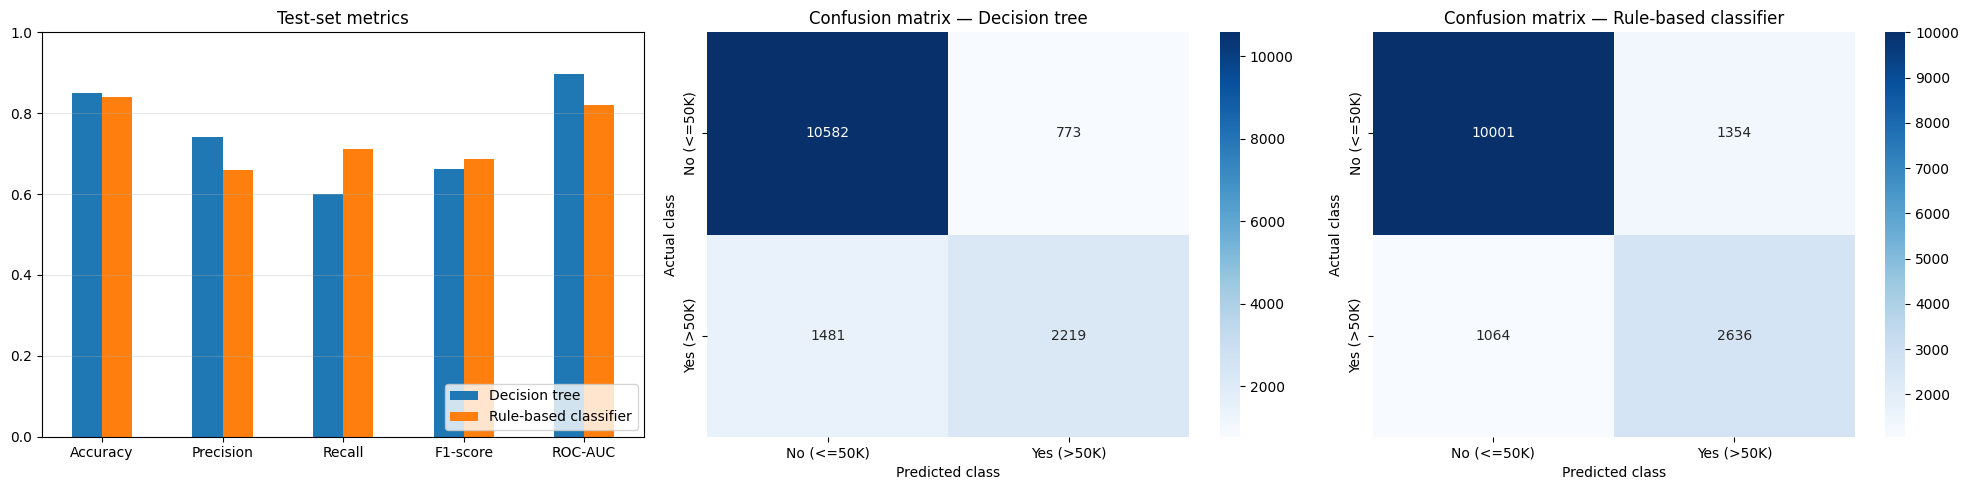

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metric_names = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
comparison[metric_names].astype(float).T.plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_ylim(0, 1)
axes[0].set_title("Test-set metrics")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend(loc="lower right")

for ax, predictions, title in [
    (axes[1], y_pred_tree, "Decision tree"),
    (axes[2], y_pred_rules, "Rule-based classifier"),
]:
    sns.heatmap(confusion_matrix(y_test, predictions, labels=[0, 1]), annot=True, fmt="d", cmap="Blues",
                xticklabels=["No (<=50K)", "Yes (>50K)"], yticklabels=["No (<=50K)", "Yes (>50K)"], ax=ax)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_title(f"Confusion matrix — {title}")

plt.tight_layout()
plt.show()